<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-failure-prediction/blob/main/Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Project  - Data Anaysis

This project contains code for MSc project about modelling time-to-failure of water mains, in particular for this is data analysis part. Relationships between Time-to-failure and remaining attributes are examined using visualisations and statistical tests.  

# Import Data and Packages

In [1]:
# import packages

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
import scipy.stats as stats


In [2]:
# mount Google Drive

drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [3]:
# import data

attributes = pd.read_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding = "latin1")


# Numerical

In this section, relationships between numerical attributes are examined using visualisations and statistical tests.



##### Exploratory Analysis

In this section, visualisations are used to examine relationships between Time-to-failure and remaining numerical attributes.

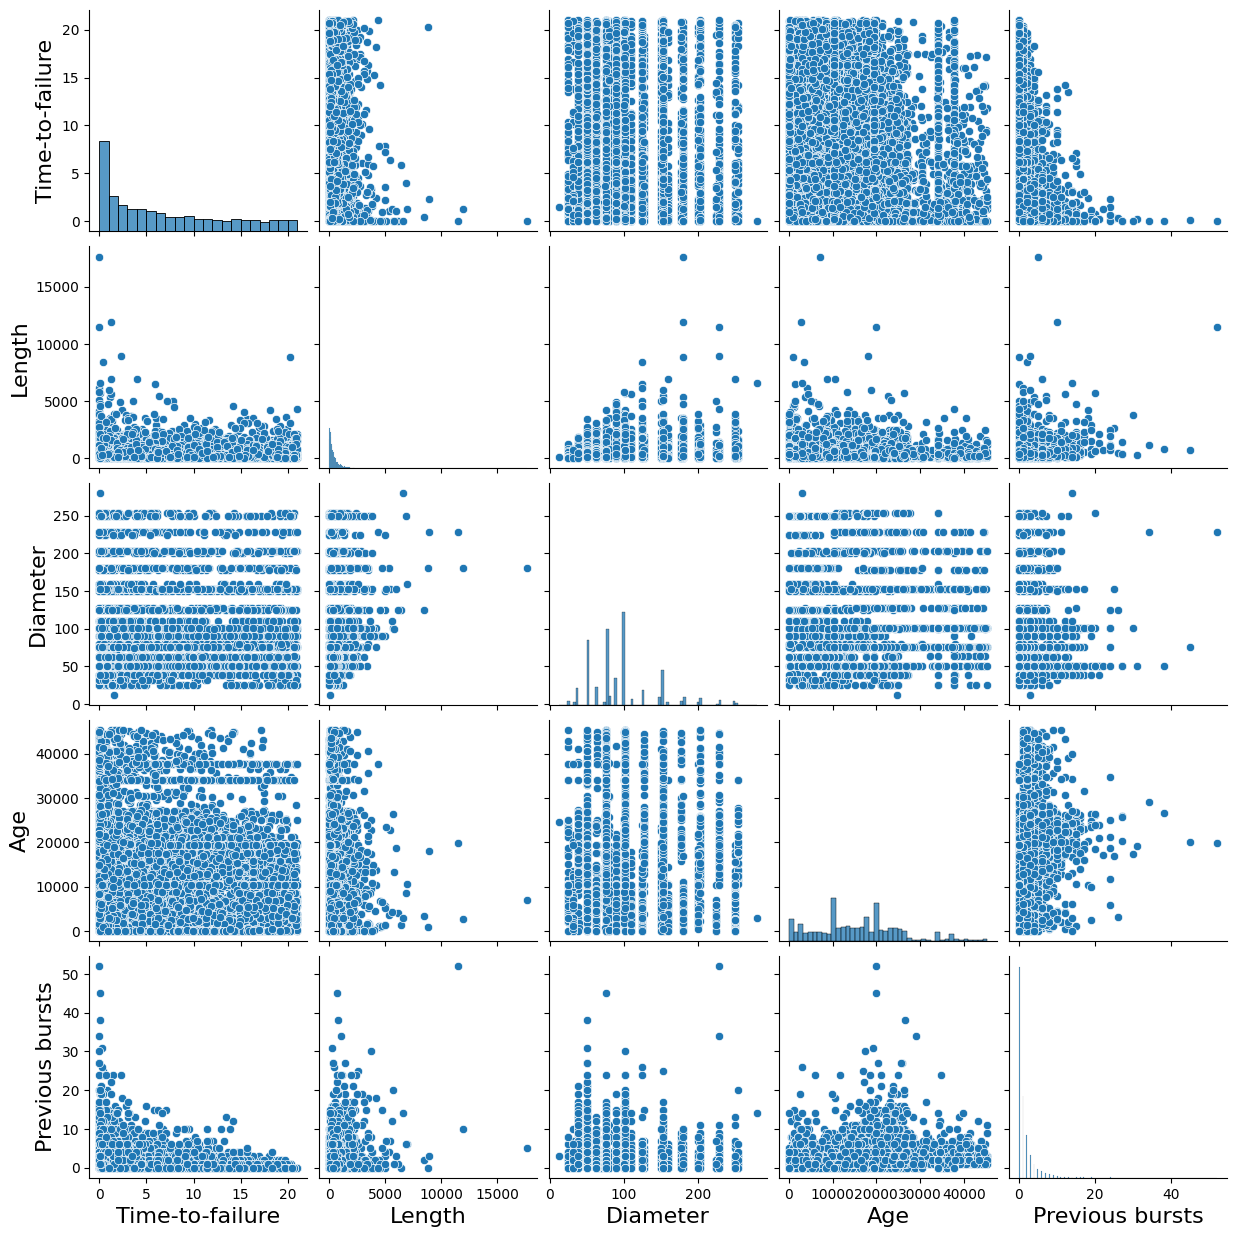

In [4]:
# Examine correlations between numerical attributes

scatter_plot_1 = sns.pairplot(attributes[["Time-to-failure", "Length", "Diameter", "Age", "Previous bursts"]])


for ax in scatter_plot_1.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_size(16)   # x-axis label
        ax.yaxis.label.set_size(16)   # y-axis label (optional)

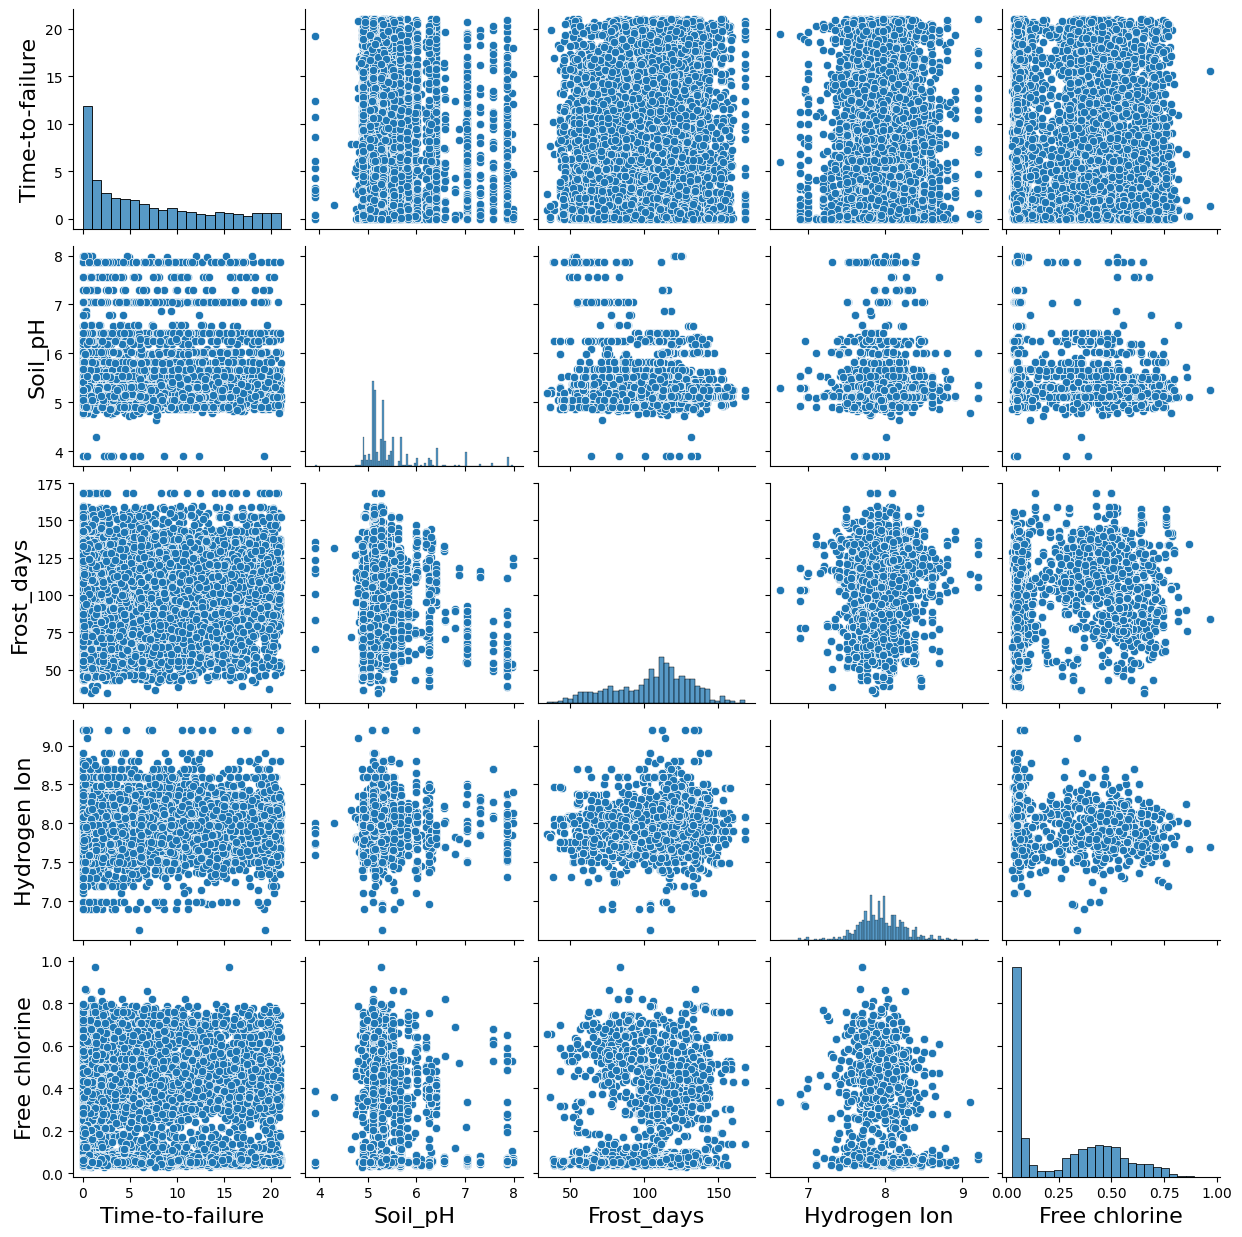

In [ ]:
# Examine correlations between numerical attributes 2

scatter_plot_2 = sns.pairplot(attributes[["Time-to-failure", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine"]])


for ax in scatter_plot_2.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_size(16)   # x-axis label
        ax.yaxis.label.set_size(16)   # y-axis label (optional)

##### Statistical Analysis

In [ ]:
# length vs time-to-break

test = stats.spearmanr(a = attributes['Length'], b = attributes["Time-to-failure"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

statistic -0.0827843397710957
p-value 1.3568371318102314e-14


In [ ]:
# diamater vs time-to-break

test = stats.spearmanr(a = attributes['Diameter'], b = attributes["Time-to-failure"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

statistic 0.03398775865904218
p-value 0.0015944097618002155


In [ ]:
# age vs time-to-break

test = stats.spearmanr(a = attributes['Age'], b = attributes["Time-to-failure"])

print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

statistic -0.1548330383121231
p-value 2.024783200434891e-47


# Categorical

In this section, relationships between Time-to-failure and remaining catergorical attributes are examined using visualisations and statsitical tests.

##### Exploratory Analysis

Text(0.5, 0, 'Material')

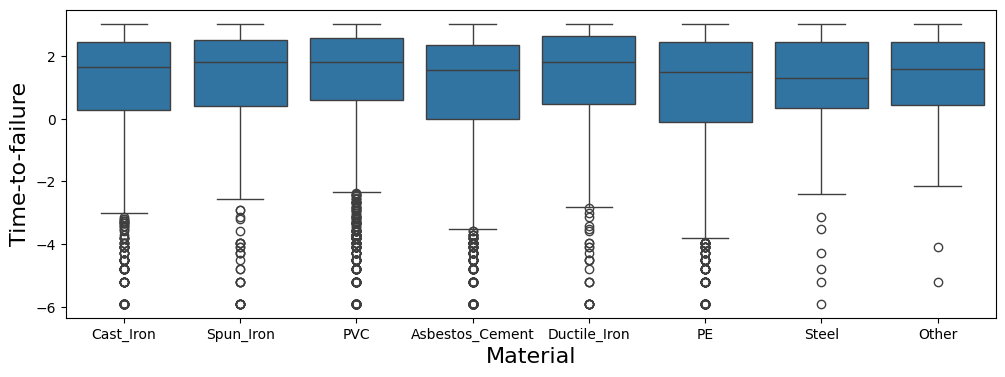

In [ ]:
plt.figure(figsize=(12,4))

sns.boxplot(
    x=attributes["Material"],
    y=np.log(attributes["Time-to-failure"]))

plt.ylabel("Time-to-failure", fontsize = 16)
plt.xlabel("Material", fontsize = 16)

Text(0.5, 0, 'Soil')

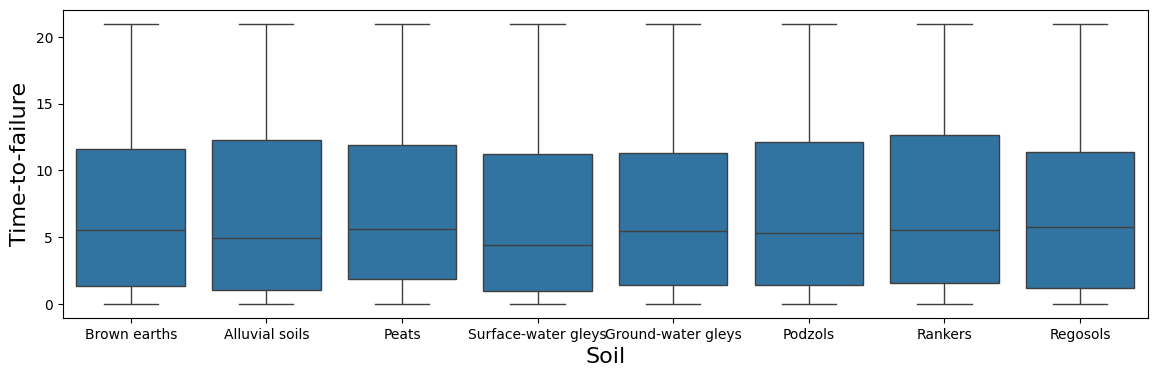

In [ ]:
plt.figure(figsize=(14,4))

sns.boxplot(
    data=attributes,
    x="Soil",
    y="Time-to-failure"
)

plt.ylabel("Time-to-failure", fontsize = 16)
plt.xlabel("Soil", fontsize = 16)

Text(0.5, 0, 'Surface')

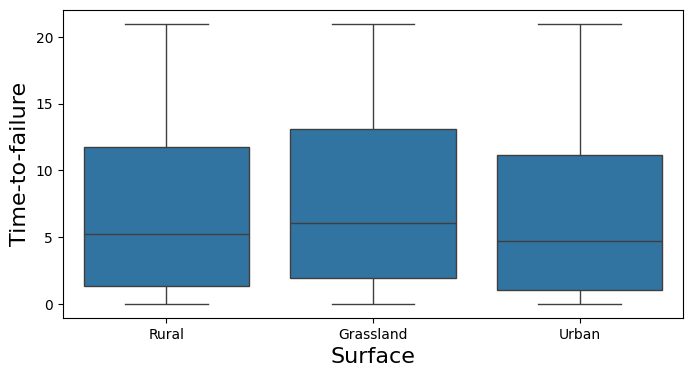

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=attributes,
    x="Surface",
    y="Time-to-failure"
)

plt.ylabel("Time-to-failure", fontsize = 16)
plt.xlabel("Surface", fontsize = 16)

Text(0.5, 0, 'Lining')

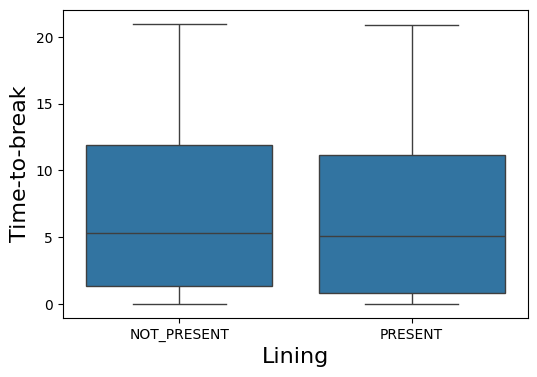

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=attributes,
    x="Lining",
    y="Time-to-break"
)

plt.ylabel("Time-to-break", fontsize = 16)
plt.xlabel("Lining", fontsize = 16)

##### Statistical Analysis

In [16]:
# split up material into categories

material_subset = attributes[["Time-to-failure", "Material"]]
material_subset['Time-to-failure'] = np.sqrt(material_subset['Time-to-failure'])
material_pivot = material_subset.pivot(values = "Time-to-failure", columns = "Material")

material_categories = {}

for material in material_pivot:

  material_categories[material] = np.array(material_pivot[material][pd.notnull(material_pivot[material])])



/tmp/ipykernel_1098/4251742452.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  material_subset['Time-to-failure'] = np.sqrt(material_subset['Time-to-failure'])


In [27]:
# one-way ANOVA for material

test = stats.f_oneway(material_categories['Cast_Iron'],
                      material_categories['Spun_Iron'],
                      material_categories['PVC'],
                      material_categories['Asbestos_Cement'],
                      material_categories['Ductile_Iron'],
                      material_categories['PE'],
                      material_categories['Steel'],
                      material_categories['Other'])

print("statistic", test.statistic)
print("p-value",  test.pvalue)

statistic 9.772034258908036
p-value 3.485070670302744e-12


In [28]:
# split up soil into categories

soil_subset = attributes[["Time-to-failure", "Soil"]]
soil_subset['Time-to-failure'] = np.sqrt(soil_subset['Time-to-failure'])
soil_pivot = soil_subset.pivot(values = "Time-to-failure", columns = "Soil")

soil_categories = {}

for soil in soil_pivot:

  soil_categories[soil] = np.array(soil_pivot[soil][pd.notnull(soil_pivot[soil])])


/tmp/ipykernel_1098/1122880476.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  soil_subset['Time-to-failure'] = np.sqrt(soil_subset['Time-to-failure'])


In [35]:
# one-way ANOVA for soil

test = stats.f_oneway(soil_categories['Brown earths'],
                      soil_categories['Alluvial soils'],
                      soil_categories['Peats'],
                      soil_categories['Surface-water gleys'],
                      soil_categories['Ground-water gleys'],
                      soil_categories['Podzols'],
                      soil_categories['Rankers'],
                      soil_categories['Regosols'])

print("statistic", test.statistic)
print("p-value",  test.pvalue)

statistic 1.6157633147877597
p-value 0.12580897765881624


In [34]:
# split up surface into categories

surface_subset = attributes[["Time-to-failure", "Surface"]]
surface_subset['Time-to-failure'] = np.sqrt(surface_subset['Time-to-failure'])
surface_pivot = surface_subset.pivot(values = "Time-to-failure", columns = "Surface")

surface_categories = {}

for surface in surface_pivot:

  surface_categories[surface] = np.array(surface_pivot[surface][pd.notnull(surface_pivot[surface])])


/tmp/ipykernel_1098/2032523761.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  surface_subset['Time-to-failure'] = np.sqrt(surface_subset['Time-to-failure'])


In [37]:
# one-way ANOVA for surface

test = stats.f_oneway(surface_categories['Grassland'],
                      surface_categories['Rural'],
                      surface_categories['Urban'])


print("statistic", test.statistic)
print("p-value",  test.pvalue)

statistic 12.350797440079688
p-value 4.403376374475806e-06


In [39]:
# split up lining into categories

lining_subset = attributes[["Time-to-failure", "Lining"]]
lining_subset['Time-to-failure'] = np.sqrt(lining_subset['Time-to-failure'])
lining_pivot = lining_subset.pivot(values = "Time-to-failure", columns = "Lining")

lining_categories = {}

for lining in lining_pivot:

  lining_categories[lining] = np.array(lining_pivot[lining][pd.notnull(lining_pivot[lining])])


/tmp/ipykernel_1098/536645299.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lining_subset['Time-to-failure'] = np.sqrt(lining_subset['Time-to-failure'])


In [40]:
# one-way ANOVA for lining


test = stats.f_oneway(lining_categories['NOT_PRESENT'],
                      lining_categories['PRESENT'])


print("statistic", test.statistic)
print("p-value",  test.pvalue)

statistic 3.057679501498223
p-value 0.08039193302593217
